# Does surprisal improve held-out reading-time prediction?

This portable notebook reads the verified summaries in `reports/`. It requires no raw corpus, GPU, model download or PC-specific path. Recompute the underlying analysis using `run.sh`; see the README. The main quantity is **R² gain in percentage points beyond controls**, alongside its uncertainty.

In [1]:
from pathlib import Path
import os, sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.report_bundle import read_summary, verify_bundle
from src.utils import focus_table, display_details
REPORTS = Path(os.environ.get("SAERT_REPORTS_DIR", ROOT/"reports"))
verify_bundle(REPORTS)
def load(section, name): return read_summary(section, name, REPORTS)
def figure(section, name): display(Image(filename=str(REPORTS/section/(name+".png"))))


Corpus,Model,Delta R2 (pp),95% interval (pp)
Provo FFD,Both contexts (identical),+1.48,"[0.54, 2.35]"
Natural Stories SPR,"1,024: current + spillover",+4.38,"[2.34, 6.34]"
Natural Stories SPR,128: current + spillover,+4.16,"[1.80, 6.00]"


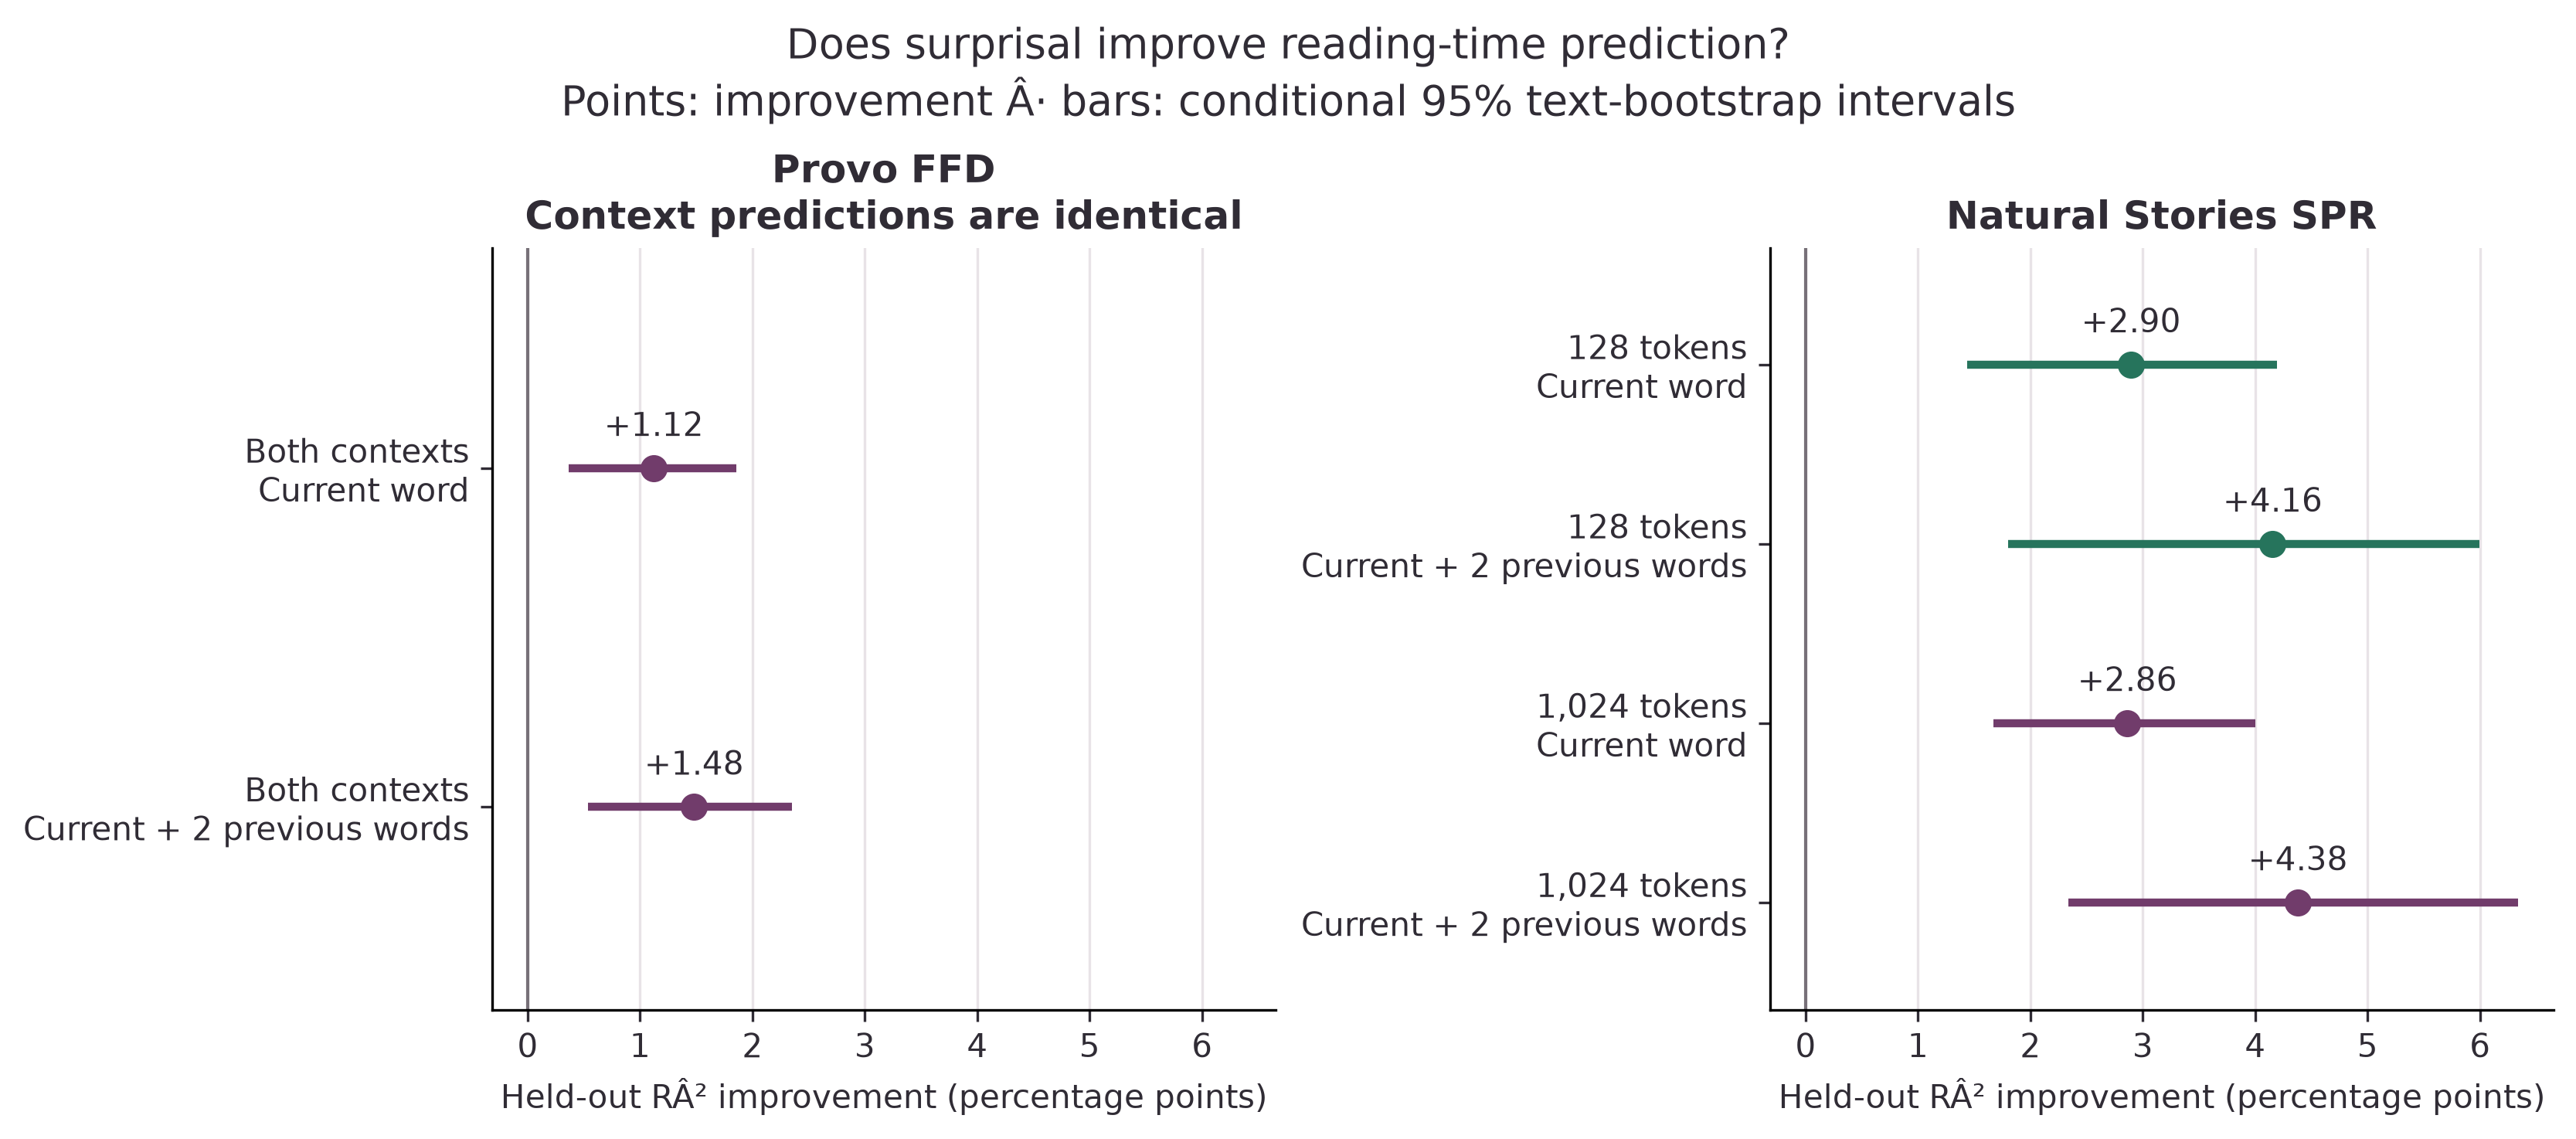

In [2]:
full = load("baseline", "model_comparison")
main = full[full.Model.str.contains("spillover")].copy()
provo = main.Corpus.str.startswith("Provo")
p = main[provo].iloc[:1].copy(); p["Model"] = "Both contexts (identical)"
main = pd.concat([p,main[~provo]])
display(focus_table(main[["Corpus","Model","Delta R2 (pp)","95% interval (pp)"]],
 important=["Delta R2 (pp)"],signed_columns=["Delta R2 (pp)"],formats={"Delta R2 (pp)":"{:+.2f}"}))
figure("baseline","heldout_improvement")

Intervals resample whole texts while holding predictions fixed. They exclude model-refitting and participant uncertainty. Provo’s context regimes coincide; Natural Stories’ context contrast does not establish an advantage.

In [3]:
display_details("Paired contrasts",load("baseline","paired_contrasts"))
display_details("Corpus quality",load("baseline","corpus_quality"))
display_details("Collinearity diagnostics",load("baseline","collinearity"))

baseline_id,corpus,candidate,reference,delta_r2,ci_low,ci_high
41c5b94b-5479-48be-9324-40659e527af0,provo,long_current,controls,0.011,0.004,0.019
41c5b94b-5479-48be-9324-40659e527af0,provo,long_spillover,controls,0.015,0.005,0.024
41c5b94b-5479-48be-9324-40659e527af0,provo,matched_current,controls,0.011,0.004,0.019
41c5b94b-5479-48be-9324-40659e527af0,provo,matched_spillover,controls,0.015,0.005,0.024
41c5b94b-5479-48be-9324-40659e527af0,provo,long_spillover,long_current,0.004,-0.001,0.008
41c5b94b-5479-48be-9324-40659e527af0,provo,matched_spillover,matched_current,0.004,-0.001,0.008
41c5b94b-5479-48be-9324-40659e527af0,provo,long_spillover,matched_spillover,0.000,0.000,0.000
bdbfa8b4-215a-483e-8116-debeb924e0b7,natural_stories,long_current,controls,0.029,0.017,0.040
bdbfa8b4-215a-483e-8116-debeb924e0b7,natural_stories,long_spillover,controls,0.044,0.023,0.063
bdbfa8b4-215a-483e-8116-debeb924e0b7,natural_stories,matched_current,controls,0.029,0.014,0.042


corpus,measure,texts,stimulus_units,eligible_RT_units,excluded_RT_units,first_units_scored,max_model_tokens_per_text,mean_RT_ms,median_RT_ms,mean_surprisal_bits,max_context_score_difference_bits
provo,FFD,55,2743,2743,0,55,81,207.670,207.229,6.202,0.000
natural_stories,SPR,10,10256,10256,0,10,1360,338.512,330.073,5.405,21.339


corpus,model,predictor,VIF_descriptive
provo,long_spillover,zipf_freq,3.170
provo,long_spillover,word_length,2.538
provo,long_spillover,is_sentence_final,1.059
provo,long_spillover,log_word_position,1.593
provo,long_spillover,is_text_position_1,5.985
provo,long_spillover,is_text_position_2,3.570
provo,long_spillover,zipf_freq_lag1,4.414
provo,long_spillover,word_length_lag1,2.749
provo,long_spillover,is_sentence_final_lag1,1.043
provo,long_spillover,zipf_freq_lag2,5.499
